- Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
- Project the dataset into the principal components, and do a scatter plot of the first two. 
- This will look terrible. Think about the units!
- Explore what happens if you rescale the data first.

**This is actually a very important lesson in machine learning**: Massaging your data before giving them to an algorithm can make things much much better.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is [the usual machine-learning approach](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) standardize your data such that each dimension has mean=0 and variance=1. 
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?



### For later: come back to this assignment after lecture 20
- Now run a supervised classification algorithm on this dataset. 
- Can you predict the stellar type? How well? Careful with overfitting of course.

In [1]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x27787091210>)

In [2]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [3]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

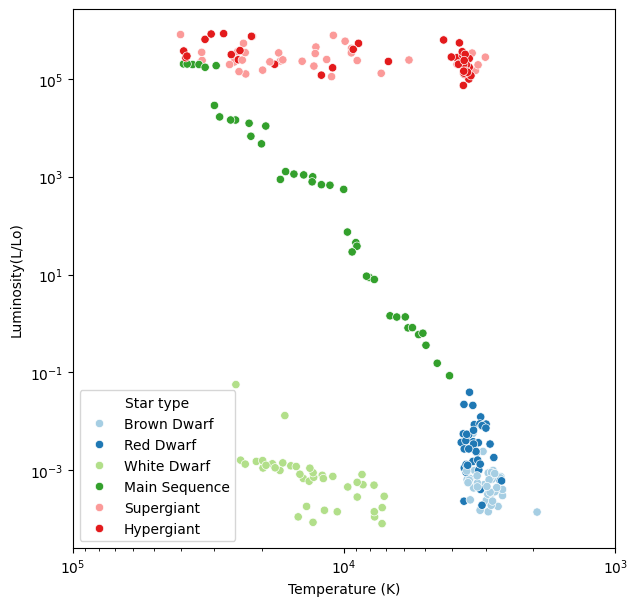

In [5]:
fig = plt.figure(figsize=(7, 7))

sns.scatterplot(data=df_stars,x='Temperature (K)',y='Luminosity(L/Lo)',hue='Star type',palette='Paired')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e5, 1E3)
plt.show()

The columns with numbers are 0 to 3: 4 features which we want to reduce to 2 using PCA.

### 1. PCA only

In [6]:
from sklearn.decomposition import PCA

In [7]:
X = np.vstack((df_stars['Temperature (K)'], df_stars['Luminosity(L/Lo)'], df_stars['Radius(R/Ro)'], df_stars['Absolute magnitude(Mv)'])).T

pca = PCA(n_components = 2)
pca.fit(X)
X_transformed = pca.transform(X)
eigenvectors = pca.components_

In [8]:
X.shape

(240, 4)

In [10]:
print(eigenvectors.shape)
print(pca.explained_variance_ratio_)

(2, 4)
[0.99760631 0.0023879 ]


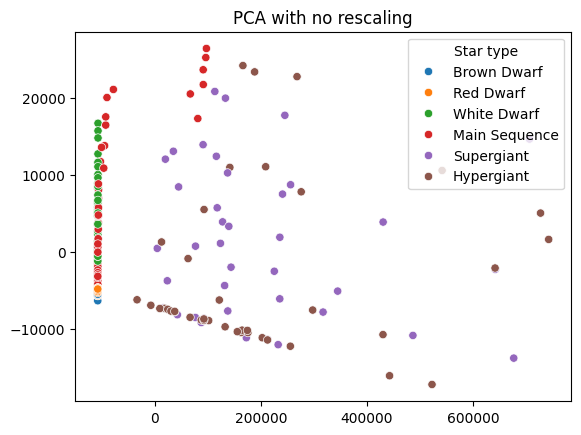

In [11]:
sns.scatterplot(x=X_transformed[:, 0], y = X_transformed[:, 1], hue=df_stars['Star type']).set(title = 'PCA with no rescaling')
plt.show()

### 2. Rescaling + PCA

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
print(scaler.mean_.shape) #1 mean for each feature
print(X_scaled.shape) 
print('Means of rescaled data: ', [np.round(np.mean(X_scaled[:, i]), 2) for i in range(4)])
print('Std dev: ', [np.round(np.std(X_scaled[:, i]), 2) for i in range(4)])

(4,)
(240, 4)
Means of rescaled data:  [np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(-0.0)]
Std dev:  [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


In [15]:
pca_scaled = PCA(n_components = 2)
X_st = pca_scaled.fit_transform(X_scaled)

[Text(0.5, 1.0, 'PCA with rescaling')]

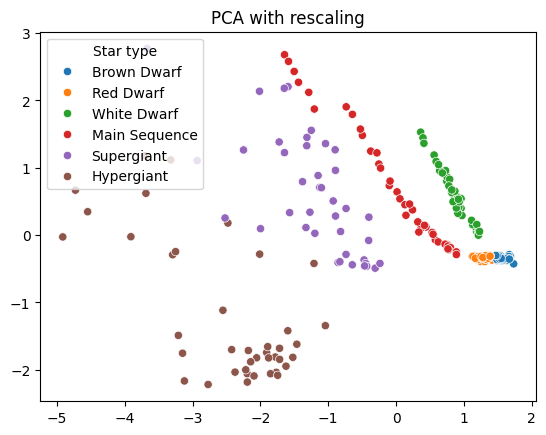

In [16]:
sns.scatterplot(x=X_st[:, 0], y = X_st[:, 1], hue=df_stars['Star type']).set(title = 'PCA with rescaling')

In [17]:
print('First component explains',pca_scaled.explained_variance_ratio_[0], ' of variance\nSecond component:',pca_scaled.explained_variance_ratio_[1])

First component explains 0.6035739091573399  of variance
Second component: 0.23500784164700797


In [18]:
print('Reducing dimentionality to 2 components explains', np.sum(pca_scaled.explained_variance_ratio_), 'of original variance')

Reducing dimentionality to 2 components explains 0.8385817508043478 of original variance
